In [3]:
import re
import os
import pandas as pd

In [14]:
def parse_script(filepath, episode_num):
    dialogues = []
    scene = 0

    # with: 파일을 열고 닫는 작업
    # r: 읽기 모드
    with open(filepath, 'r', encoding='cp949') as f:
        # 파일 전체를 한 줄씩 나눠서 리스트로 읽기
        lines = f.readlines()

    for line in lines:
        line = line.strip() # 문자열 앞뒤 공백, 줄바꿈 제거

        # 장면 번호 감지
        if re.match(r'^#\d+', line):
            scene = int(re.match(r'^#(\d+)', line).group(1))

        # 대사 감지
        match = re.match(r'^([가-힣a-zA-Z\s]{1,10})\s*:\s*(.+)', line)
        if match:
            character = match.group(1).strip()
            dialogue = match.group(2).strip()
            dialogues.append({
                'character': character,
                'dialogue': dialogue,
                'scene': scene,
                'episode': episode_num
            })

    return dialogues

In [16]:
# 1회 파일로 테스트
result = parse_script('data/동이_1회.txt', 1)
df = pd.DataFrame(result)
# print("총 대사 수: " + str(len(df)))
print(f"총 대사 수: {len(df)}")
print(df.head(10))

총 대사 수: 500
  character                               dialogue  scene  episode
0        노인                               ...어부인가?      2        1
1        삿갓                      (고개 안 든 채. 낮게) 예.      2        1
2        노인                         이른 시간에 바지런하구만.      2        1
3        삿갓        ........(가만...낚시도구 정리하던 손을 멈춘다)      2        1
4        삿갓         그런 것 까지 일러주시다니...고맙습니다 장익헌 영감.      2        1
5        노인          (멈칫, 의아한 얼굴로 본다) ...나를...아는가?      2        1
6        삿갓                              .........      2        1
7        노인                (당혹) 누...누구냐? 누군데 나를...      2        1
8        여인  ...저는....더 이상 못갈 것 같습니다. 아이를 데리고 가세요.      3        1
9        사내              그런 소리 말게. 예서 잡히면 살아남지 못해!      3        1


In [17]:
all_dialogues = []

for i in range(1, 61):  # 60부작
    filepath = f'data/동이_{i}회.txt'
    result = parse_script(filepath, i)

    # 회차 정보 추가
    for item in result:
        item['episode'] = i

    all_dialogues.extend(result)

df_all = pd.DataFrame(all_dialogues)
print(f"전체 대사 수: {len(df_all)}")
print(df_all.head())

전체 대사 수: 29925
  character                         dialogue  scene  episode
0        노인                         ...어부인가?      2        1
1        삿갓                (고개 안 든 채. 낮게) 예.      2        1
2        노인                   이른 시간에 바지런하구만.      2        1
3        삿갓  ........(가만...낚시도구 정리하던 손을 멈춘다)      2        1
4        삿갓   그런 것 까지 일러주시다니...고맙습니다 장익헌 영감.      2        1


In [18]:
# 인물별 대사 수 집계
character_count = df_all['character'].value_counts()
print(character_count.head(20))

character
동이     5997
숙종     3157
옥정     2023
서용기    1495
천수     1476
장희재    1110
연잉군     753
정상궁     630
인현      619
심운택     594
봉상궁     581
영달      573
장무열     561
오태석     441
오윤      408
세자      392
유상궁     353
정임      350
윤씨      345
조상궁     335
Name: count, dtype: int64


In [11]:
# 인물 이름이 다르게 표기된 건 없는지 확인
pd.set_option('display.max_rows', None)  # 행 제한 없이 전부 표시
print(character_count)

character
동이           5997
숙종           3157
옥정           2023
서용기          1495
천수           1476
장희재          1110
연잉군           753
정상궁           630
인현            619
심운택           594
봉상궁           581
영달            573
장무열           561
오태석           441
오윤            408
세자            392
유상궁           353
정임            350
윤씨            345
조상궁           335
황주식           305
애종            296
박씨            256
호양            241
다들            238
인원            233
설희            224
게둬라           224
주식            213
태풍            206
대전내관          195
정인국           194
부관            186
안상궁           176
도승지           173
황부장           167
대비            164
영선            156
최효원           155
민군관           149
김구선           147
상선            140
시비            131
은금            129
오태풍           126
임상현           106
김환             96
오호양            94
홍태윤            83
군관             80
변가             78
집사             75
동주             70
태감             66
수하             66


In [19]:
name_mapping = {
    '동  이': '동이',
    '숙 종': '숙종',
    '희빈': '옥정',
    '희재': '장희재',
    '장희제': '장희재',
    '영조': '연잉군',
    '연잉궁': '연잉군',
    '연인군': '연잉군',
    '금': '연잉군',
    '금이': '연잉군',
    '중전': '인현',
    '운택': '심운택',
    '심운태': '심운택',
    '정  임': '정임',
    '윤시': '윤씨',
    '애  종': '애종',
    '오호양': '호양',
    '설아': '설희',
    '오태풍': '태풍',
    '상선': '대전내관',
    '대저낸관': '대전내관',
    '대전 내관': '대전내관',
    '한내관': '대전내관',
    '정인구': '정인국',
    '나인 영선': '영선',
    '게둬라 부': '게둬라부',
}

df_all['character'] = df_all['character'].replace(name_mapping)

print(df_all['character'].value_counts().head(20))

character
동이      6000
숙종      3158
옥정      2036
서용기     1495
천수      1476
장희재     1123
연잉군      769
심운택      639
정상궁      630
인현       628
봉상궁      581
영달       573
장무열      561
오태석      441
오윤       408
세자       392
유상궁      353
정임       351
윤씨       346
대전내관     338
Name: count, dtype: int64


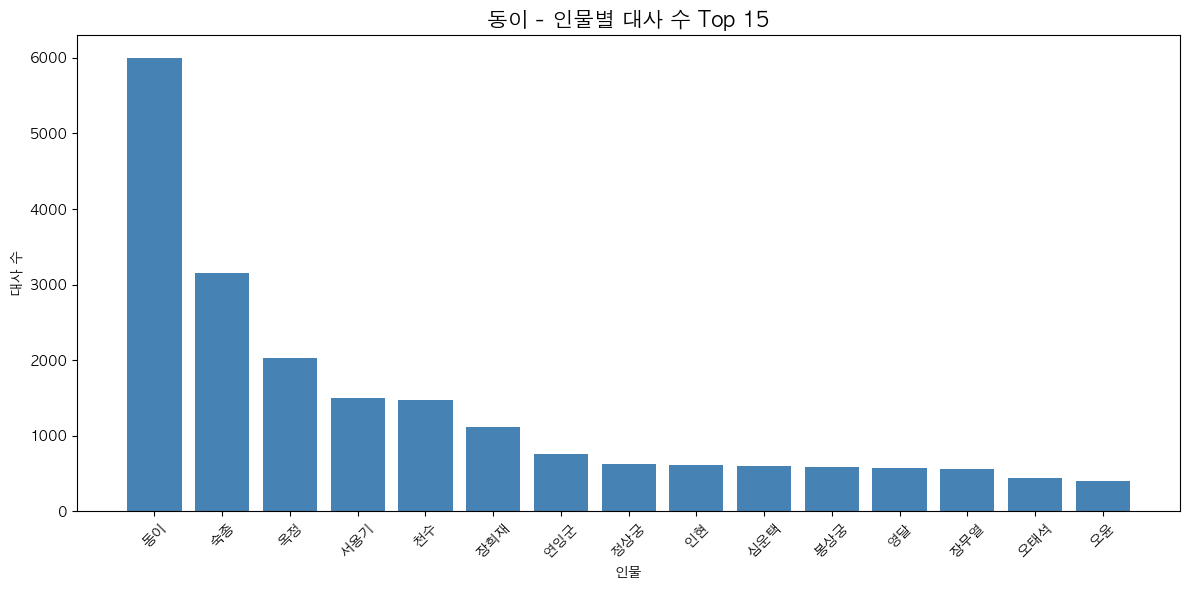

In [21]:
# 인물별 대사 수 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

top15 = character_count.head(15)

plt.figure(figsize=(12,6))
plt.bar(top15.index, top15.values, color='steelblue')
plt.title('동이 - 인물별 대사 수 Top 15', fontsize=15)
plt.xlabel('인물')
plt.ylabel('대사 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
import networkx as nx
from itertools import combinations

In [25]:
# 장면별로 등장한 인물들 묶기
scene_groups = df_all.groupby(['episode', 'scene'])['character'].unique()
print(scene_groups)

episode  scene
1        2                                                 [노인, 삿갓]
         3                                                 [여인, 사내]
         4                                                [추쇄들, 천수]
         5                                       [노복내외, 사내, 천수, 동주]
         6                                                 [천수, 동주]
         11                                           [남아, 동이, 게둬라]
         12                                                [동이, 남아]
         15                 [아이들, 누더기 아이들, 창말 아이들, 동이, 어른, 게둬라, 남아]
         16                                                [동이, 남아]
         17                                       [남아, 동이, 게둬라, 노인]
         18                                                    [동이]
         20                                                    [동이]
         22                                          [군관, 오태석, 중신들]
         24                                          [동이, 장부장, 황부장]
         25                      

In [24]:
pd.set_option('display.max_rows', None)

In [26]:
# 네트워크 그래프 생성
G = nx.Graph()

for characters in scene_groups:
    # 한 장면에 2명 이상 등장한 경우만
    if len(characters) >= 2:
        # 등장 인물들끼리 모든 조합으로 연결
        for char1, char2 in combinations(characters, 2):
            if G.has_edge(char1, char2):
                G[char1][char2]['weight'] += 1
            else:
                G.add_edge(char1, char2, weight=1)
            
print(f'인물 수: {G.number_of_nodes()}')
print(f'연결 수: {G.number_of_edges()}')

인물 수: 276
연결 수: 2323


In [29]:
# 특정 회차의 네트워크 그래프 생성 함수
def make_episode_graph(episode_num):
    G = nx.Graph()

    # 해당 회차만 필터링
    episode_scenes = df_all[df_all['episode'] == episode_num].groupby('scene')['character'].unique()

    for characters in episode_scenes:
        if len(characters) >= 2:
            for char1,char2 in combinations(characters, 2):
                if G.has_edge(char1, char2):
                    G[char1][char2]['weight'] += 1
                else:
                    G.add_edge(char1, char2, weight=1)
    
    return G

In [30]:
# 1회 테스트
G_ep1 = make_episode_graph(1)
print(f"1회 인물 수: {G_ep1.number_of_nodes()}")
print(f"1회 연결 수: {G_ep1.number_of_edges()}")

1회 인물 수: 37
1회 연결 수: 96
